# Exercise: Federalist papers

Peter Ralph  
2026-02-06

# Hands on with some text: the federalist papers

We’ve had a look at doing dimension reduction with the [federalist
papers](../slides/federalist.html). Today, you’re going to continue with
this. The main skills here are being able to identify and articulate:

-   What is this dimension reduction telling us?
-   Is that what I want, and if not, what do I do about it?

This is important because there’s lots of different dimension reduction
techniques, and data pre-processing steps that can be important, and to
be effective with these you need to be able to figure these things out.

## Setup

In [1]:
import json, re
import pandas as pd
import numpy as np
import plotnine as p9
from collections import Counter
import scipy

## The data

As before, you can get the data from this file:
[data/federalist.json](../data/federalist.json). It is a text file,
where each line is a JSON entry, containing: `author`, `text`, `date`,
`title`, `paper_id`, and `venue`.

Here’s the code we developed in class to read in and clean the data:

In [2]:
with open("data/federalist.json", 'r') as f:
    text = [json.loads(line) for line in f]

info = pd.DataFrame(
    { k: [t[k] for t in text] for k in ['author', 'date', 'title', 'paper_id', 'venue']}
).assign(length = [len(t['text'].split(" ")) for t in text])

def clean(t):
    t = re.sub("[\n\t]", " ", t).lower()
    t = re.sub("[^a-z ]", "", t)
    t = re.sub("  *", " ", t)
    t = t.strip()
    return t

# the first word is "empty string" for some reason; we drop it
words = np.unique(" ".join([clean(t['text']) for t in text]).split(" "))

def tabwords(x, words):
    d = Counter(x.split(" "))
    out = np.array([d[w] for w in words])
    return out

wordmat = np.array([tabwords(clean(t['text']), words) for t in text])

## PCA

Here’s a helper function to do PCA with SVD:

In [3]:
def svd_pca(x, words, num_pcs=4):
    pcs, evals, evecs = scipy.sparse.linalg.svds(x, k=num_pcs)
    eord = np.argsort(evals)[::-1]
    evals = evals[eord]
    evecs = evecs[eord,:]
    pcs = pcs[:,eord]
    pc_df = pd.concat([
        info,
        pd.DataFrame({f"PC{k+1}" : pcs[:,k] for k in range(pcs.shape[1])})
    ], axis=1)
    loadings = pd.DataFrame(evecs.T, columns=[f"PC{k+1}" for k in range(pcs.shape[1])], index=words)
    return pc_df, loadings, evals

# No normalization

We first decided to normalize *rows*, so that the matrix we’re using has
“what proportion of the words in this essay were *w*” for each word *w*,
rather than a total count: John Jay fell out low on PC1.

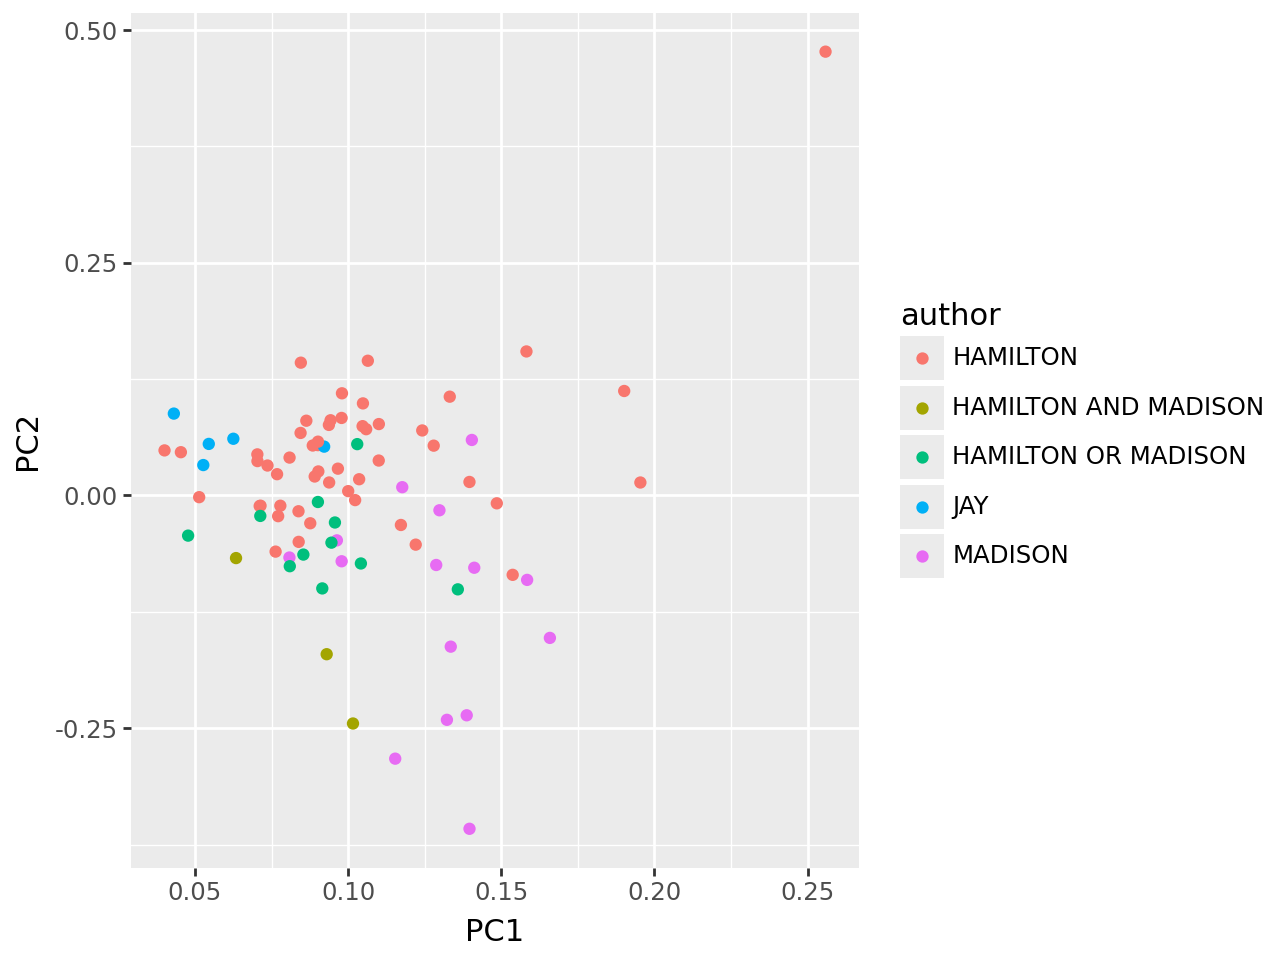

In [4]:
x = wordmat
pc_df, loadings, _ = svd_pca(x, words)

p9.ggplot(pc_df, p9.aes(x="PC1", y="PC2", color="author")) + p9.geom_point()

## It’s ‘length’.

Interpretation:

PC1 tells us mostly about “length of the essay”. This is maybe a good
thing to know (eg Hamilton wrote the longest one) but not very
interesting or relevant in this context.

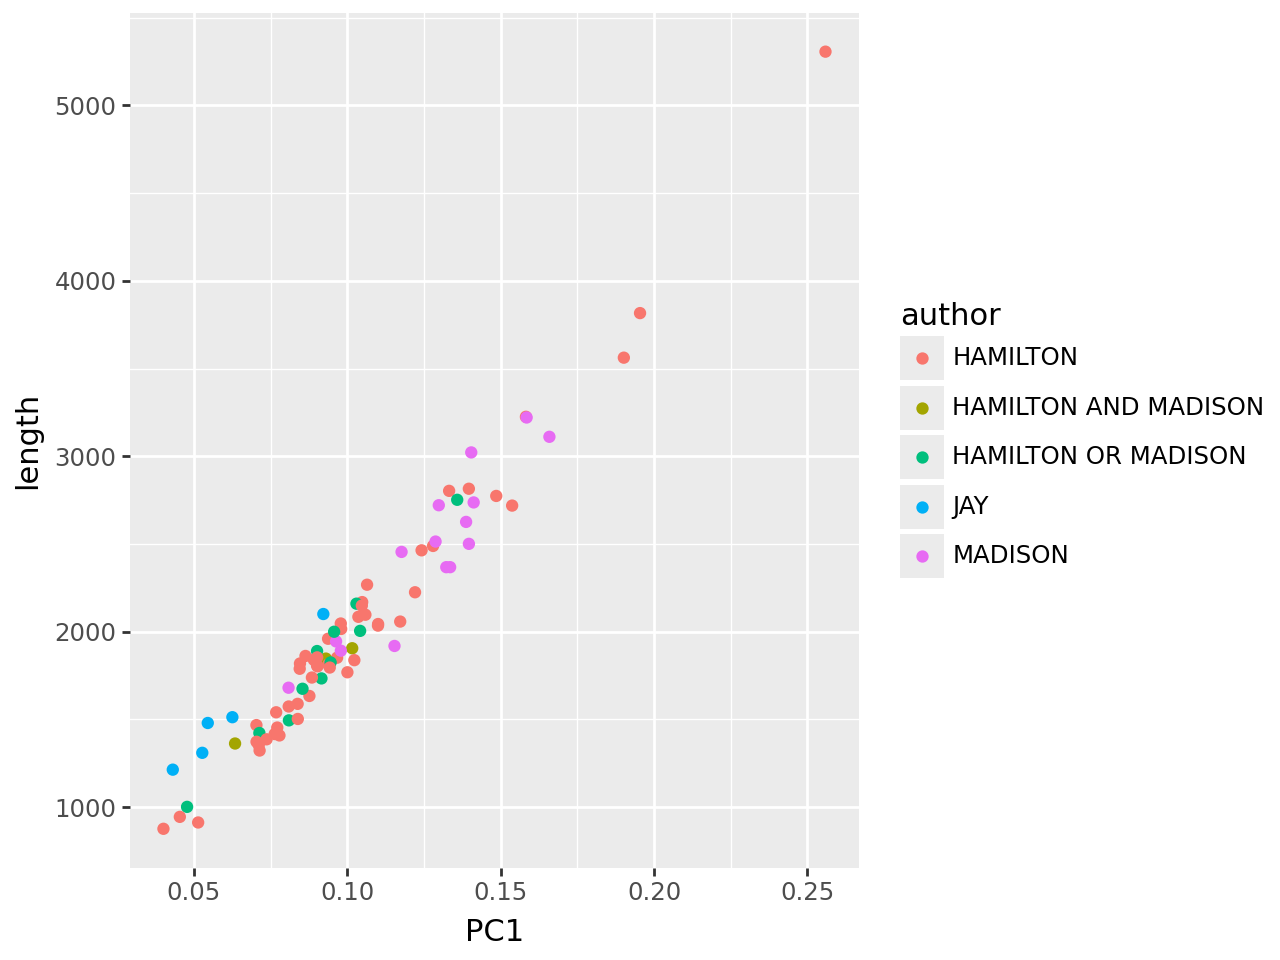

In [5]:
p9.ggplot(pc_df, p9.aes(x="PC1", y="length", color="author")) + p9.geom_point()

# Normalize rows

So, to remove this, we decided to normalize\* *rows*, so that the matrix
we’re using has “what proportion of the words in this essay were *w*”
for each word *w*, rather than a total count. This should remove the
effect of length. In the resulting PCs, John Jay falls out low on PC1.

*Note:* “normalize” sometimes means a specific thing (“subtract mean and
divide by SD”) but that’s not how I’m using it here.

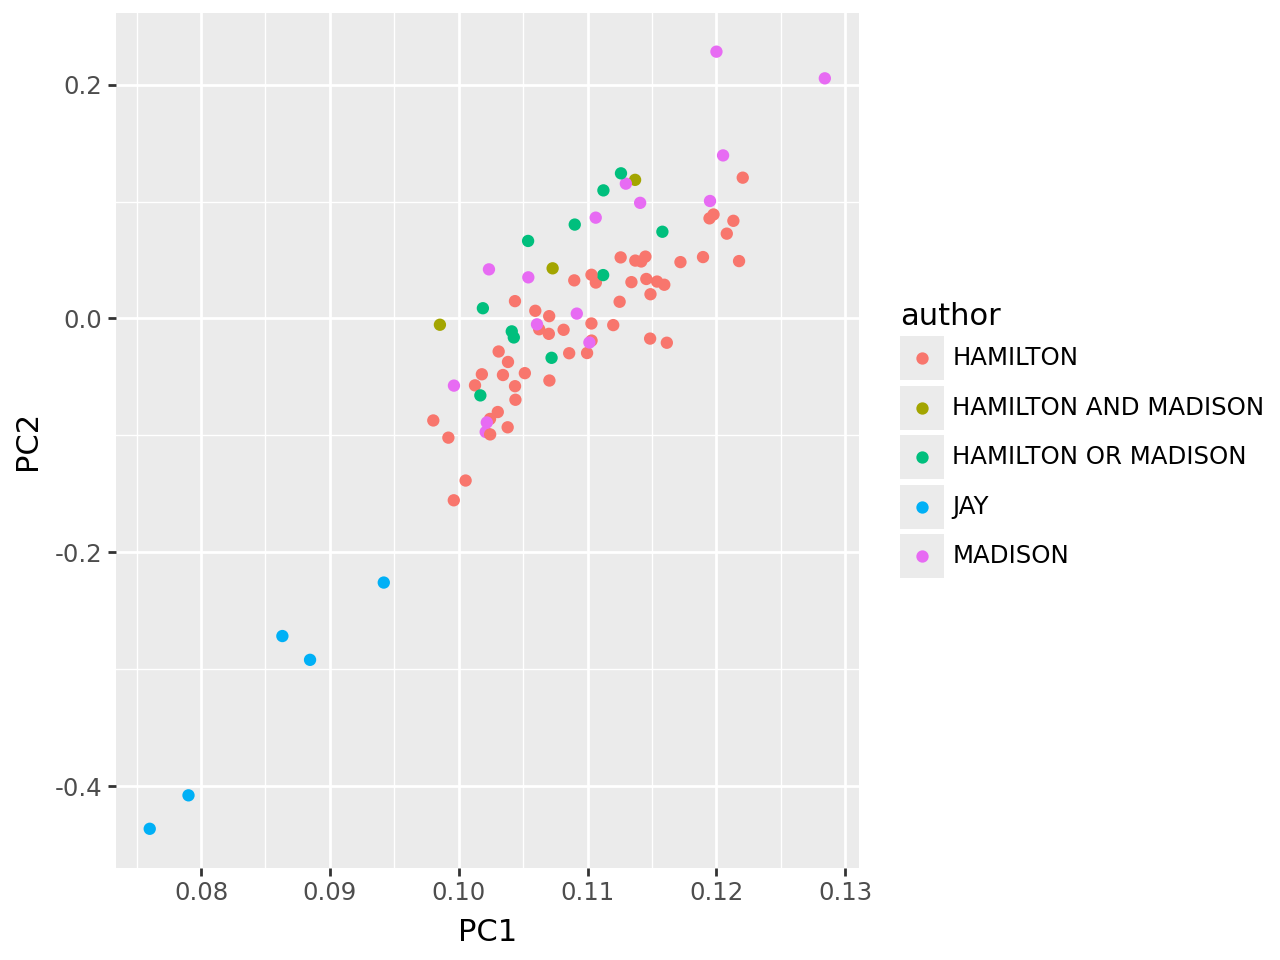

In [6]:
x = wordmat / np.sum(wordmat, axis=1)[:, np.newaxis]
pc_df, loadings, _ = svd_pca(x, words)

p9.ggplot(pc_df, p9.aes(x="PC1", y="PC2", color="author")) + p9.geom_point()

## What’s going on with this?

*Assignment:*

1.  Look at the loadings below, and interpret this in terms of “which
    words does Jay tend to use more, and which less”.

2.  Compute the *frequency* of each word (i.e., how often is it used in
    the essays), and add this to the `loadings` data frame. Plot this
    frequency against PC1. Does this help your conclusion?

In [7]:
loadings['frequency'] = wordmat.sum(axis=0)

In [8]:
loadings.sort_values("PC1").head(n=30)

,PC1,PC2,PC3,PC4,frequency
quadrate,0.000014,-0.000045,-0.000183,0.00002,1
accessible,0.000014,-0.000045,-0.000183,0.00002,1
wilful,0.000014,-0.000045,-0.000183,0.00002,1
surmount,0.000014,-0.000045,-0.000183,0.00002,1
senseless,0.000014,-0.000045,-0.000183,0.00002,1
indispose,0.000014,-0.000045,-0.000183,0.00002,1
obliging,0.000014,-0.000045,-0.000183,0.00002,1
canon,0.000014,-0.000045,-0.000183,0.00002,1
explore,0.000014,-0.000045,-0.000183,0.00002,1
misapprehensions,0.000014,-0.000045,-0.000183,0.00002,1


In [10]:
loadings.sort_values("PC1").tail(n=30)

,PC1,PC2,PC3,PC4,frequency
may,0.031706,-0.017920,-0.036224,0.081347,812
states,0.032364,0.035431,0.007890,-0.017861,845
government,0.032737,-0.017675,0.051085,0.138948,823
they,0.035837,-0.126724,0.051232,0.023311,927
an,0.036602,-0.002410,-0.086499,-0.048685,927
on,0.036625,0.017005,0.143751,0.049852,947
are,0.039543,-0.056151,0.048076,0.036129,1029
from,0.041182,-0.069344,0.006991,-0.001865,1042
with,0.041636,-0.057788,0.042652,-0.047109,1048
their,0.043492,-0.130353,0.110207,0.036838,1095


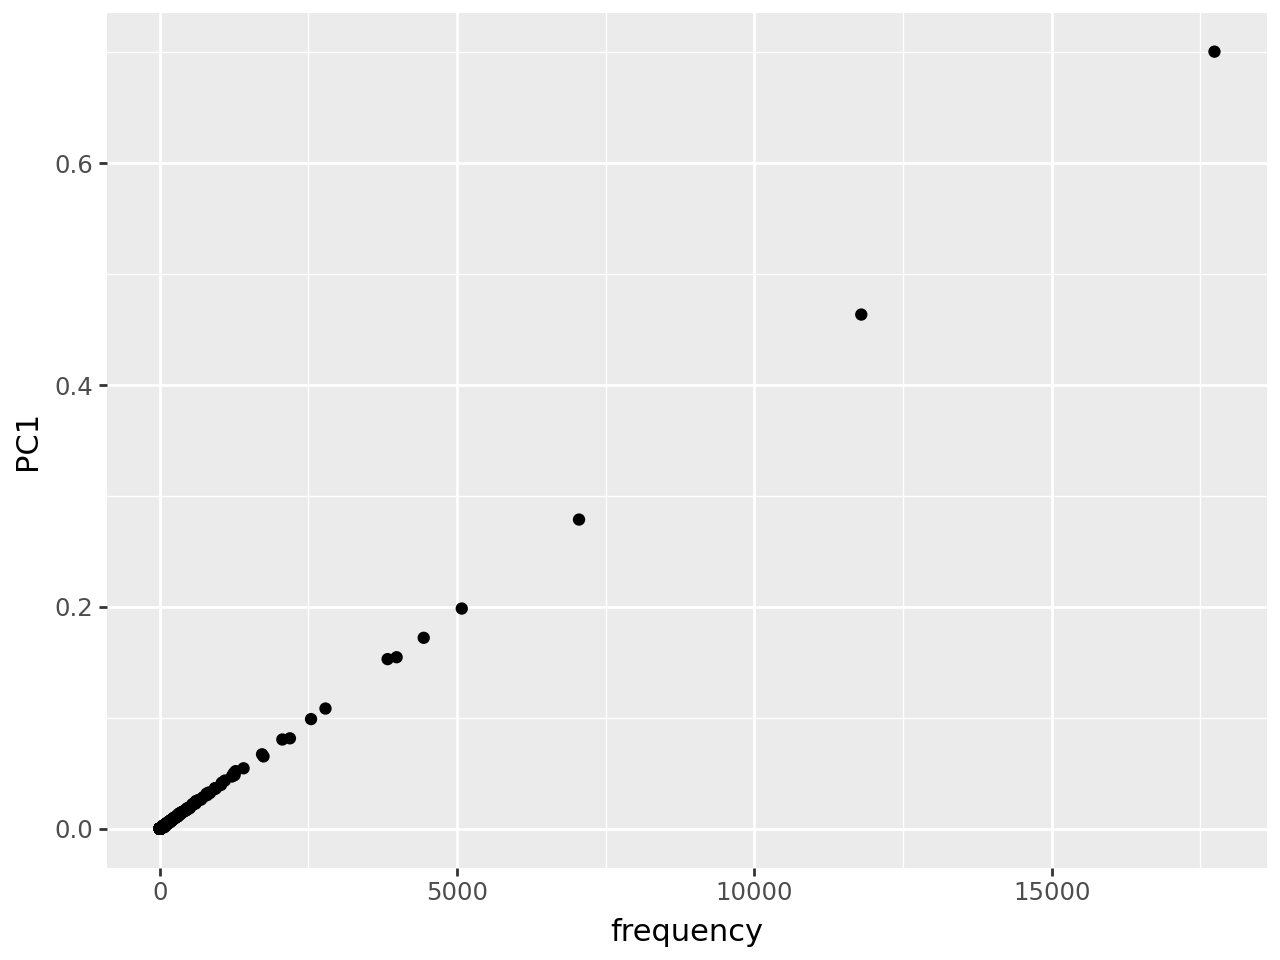

In [11]:
p9.ggplot(loadings, p9.aes(x='frequency', y='PC1')) + p9.geom_point()

# And also columns

Next, let’s see what happens if we also normalize columns.

*Assignment:*

1.  Modify the code below to *also* subtract the mean from each column
    (after the row normalization).
2.  What are the main features of the resulting PCs? Can you explain
    these?

In [16]:
np.array([[0,1,2],[3,4,5]]) - np.array([1, 5, 10])

array([[-1, -4, -8],
       [ 2, -1, -5]])

In [19]:
x = wordmat / np.sum(wordmat, axis=1)[:, np.newaxis]
x -= x.mean(axis=0)
x.shape

(85, 8715)

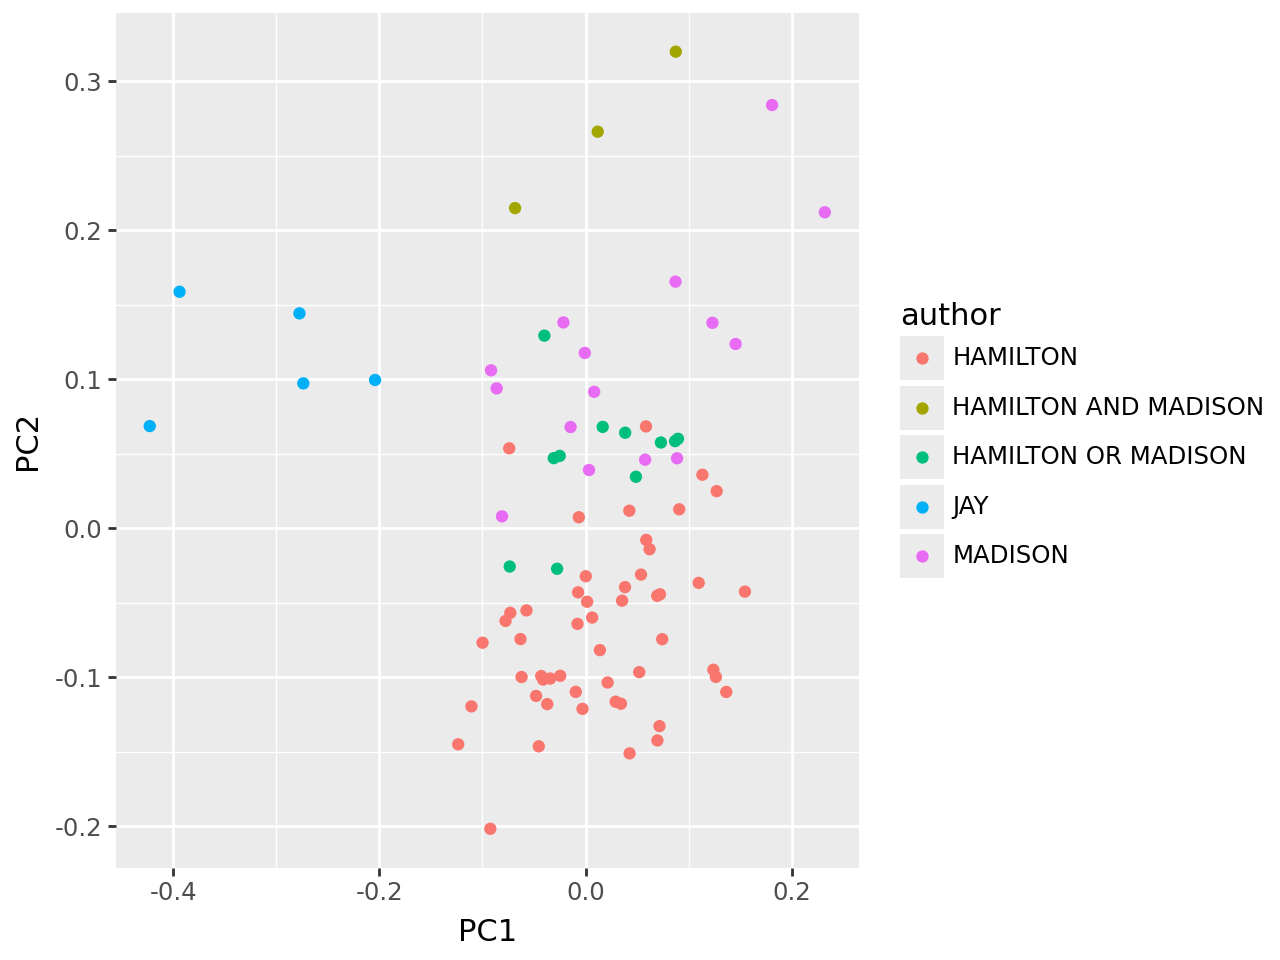

In [20]:
pc_df, loadings, _ = svd_pca(x, words)

p9.ggplot(pc_df, p9.aes(x="PC1", y="PC2", color="author")) + p9.geom_point()

In [21]:
loadings.sort_values("PC1").head(n=30)

,PC1,PC2,PC3,PC4
and,-0.307995,0.474742,0.079130,0.278246
their,-0.077006,0.090488,-0.038871,-0.013677
our,-0.075949,-0.013453,0.026799,0.037041
they,-0.075066,0.032780,-0.025120,0.010749
nations,-0.059611,0.009336,0.014390,0.033133
would,-0.056251,-0.212464,0.093016,0.031715
or,-0.052732,-0.007498,-0.044019,0.063763
us,-0.040158,-0.014756,0.013258,0.023433
more,-0.039601,0.032001,-0.026154,-0.027603
one,-0.036454,0.031647,-0.008395,0.005821


In [23]:
loadings.sort_values("PC1").tail(n=30)

,PC1,PC2,PC3,PC4
supreme,0.020057,0.001840,-0.023684,0.039602
no,0.020488,-0.001736,-0.011172,-0.034817
legislature,0.020571,-0.007733,-0.005287,-0.032044
cases,0.021937,0.007773,-0.015071,0.018621
court,0.022781,-0.012896,-0.012283,0.031283
judiciary,0.022865,0.033705,-0.004433,0.006541
been,0.023521,-0.009177,0.028966,-0.049465
body,0.024284,-0.034068,0.001130,-0.018191
department,0.025149,0.054246,0.007022,-0.041548
powers,0.026316,0.077618,-0.003884,0.021505


# More on the columns

*Assignment:* 

1. As in the previous assignment, but *also* divide the
columns by their SD.

2. Question: is this going to make rare words more
or less important?


3. What are the main features of the resulting PCs?
Can you explain these?

We'd expect that this will make rare words more important.
The reason for this is that the numbers in columns for common words are bigger
(since those numbers are frequencies of the word),
and in general if you have two vectors, one with big numbers and the other with small numbers,
we expect the SD of the vector of big numbers to be bigger.
This isn't always true, of course: if all the big numbers are the same, then the SD is zero.
But: if the typical essay has around 50 "a"s, then it'll be easy for different essays to have maybe 45 or 55 "a"s
(so an SD of around 5), while if the word "carnage" only appears 3 times over the 85 essays,
it certainly can't have and SD bigger than 1.
So - we will divide the columns for common words by a (typically) bigger number,
thus downweighting the common words.

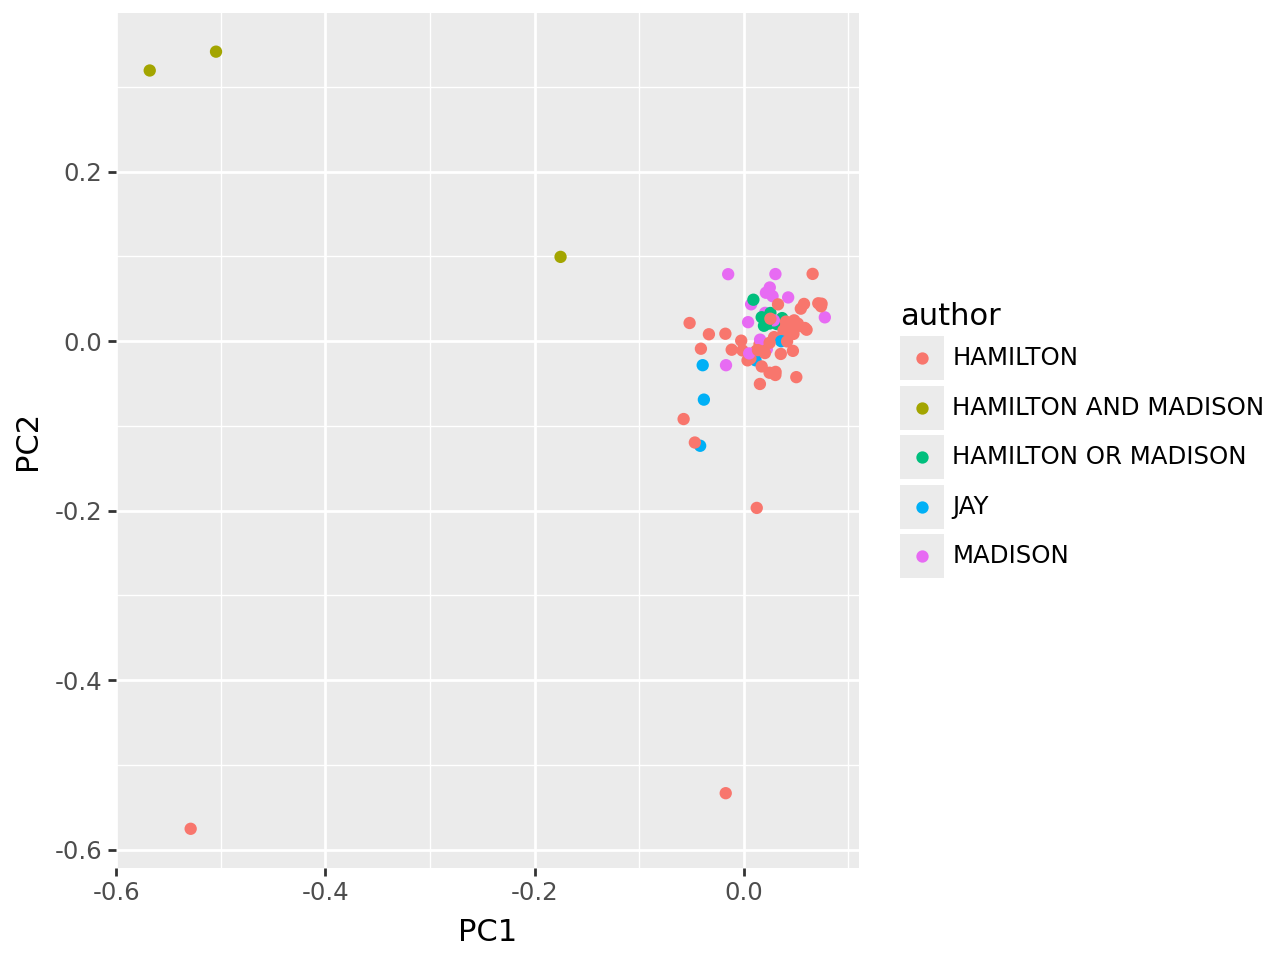

In [24]:
x = wordmat / np.sum(wordmat, axis=1)[:, np.newaxis]
x -= x.mean(axis=0)
x /= x.std(axis=0)
pc_df, loadings, _ = svd_pca(x, words)

p9.ggplot(pc_df, p9.aes(x="PC1", y="PC2", color="author")) + p9.geom_point()

Looking at this PC plot, we see a lot less structure than in previous plots.
There's just a few essays that stick out in the negative direction on both PC1 and PC2.
This doesn't seem very informative.

We can look at whether common or rare words have high loadings on PC1 and PC2
in this next plot, showing frequency (on a log scale) across all essays against PC1 and PC2.
It looks like the positive direction in PC1 has more common words, while the biggest negative loadings are rare words
(mostly, found less than 100 times). On PC2, it's rare words that have the biggest loadings in both directions.

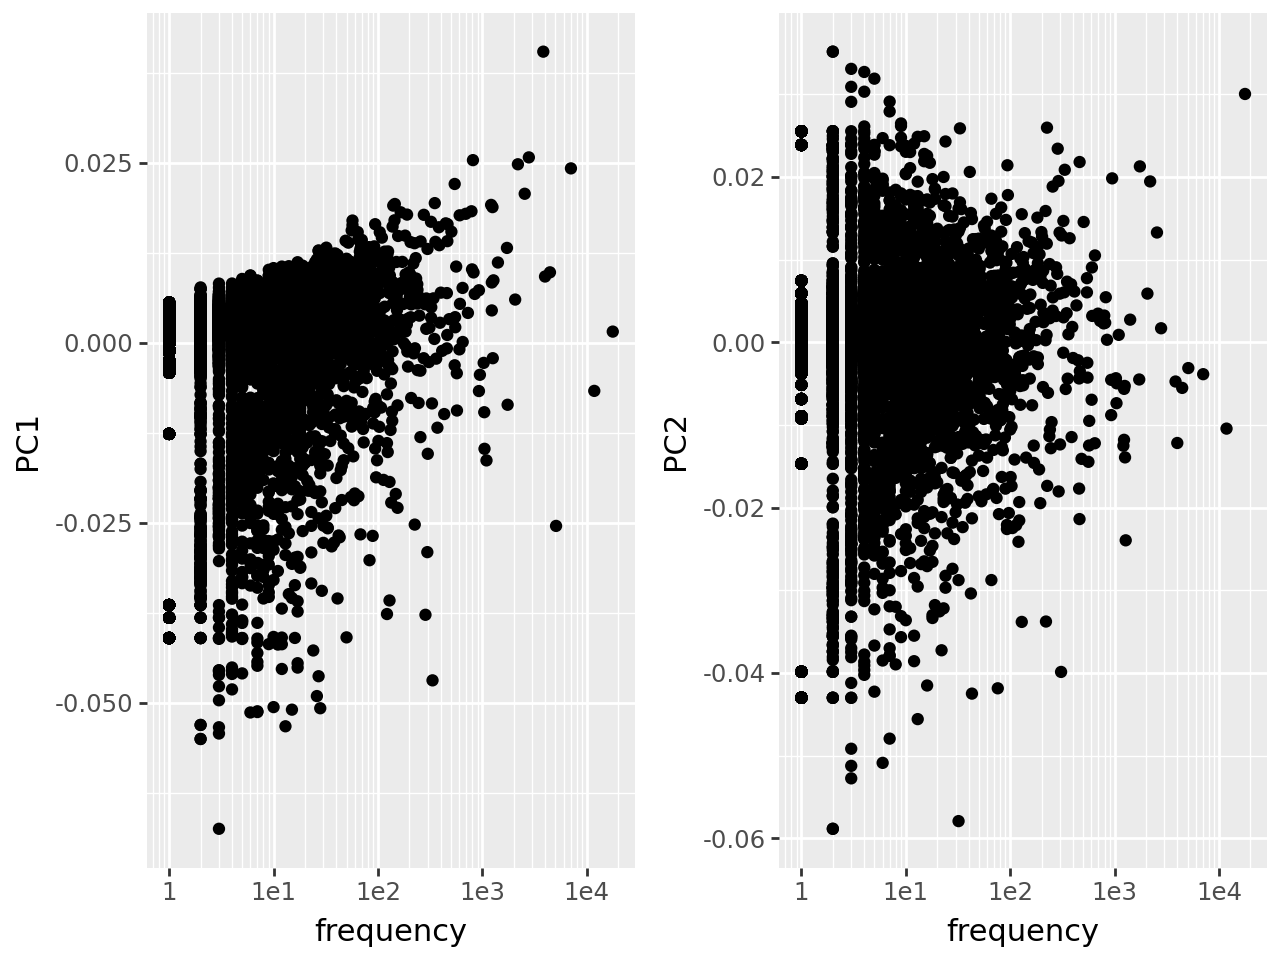

In [36]:
loadings['frequency'] = wordmat.sum(axis=0)
(
    p9.ggplot(loadings, p9.aes(x='frequency', y='PC1')) + p9.geom_point() + p9.scale_x_log10()
) | (
    p9.ggplot(loadings, p9.aes(x='frequency', y='PC2')) + p9.geom_point() + p9.scale_x_log10()
)

Looking at the loadings for particular words (in the next two tables),
we see that the words with the largest negative loadings on PC1 (first table)
and PC2 (second table) are indeed rare, like "carnage", "grecian", "dismembered", and "princes".
Oddly, "around" is rare here (used 2 times): maybe that was less common at the time.
These words are rare, and - importantly - don't seem particularly informative or interesting.

Overall, it seems like scaling the columns in the word matrix by the SD was not a good idea,
because it downweighted the common words, leading to the structure in the dataset
being dominated by rare and hard-to-generalize patterns of rare words.

In [39]:
loadings.sort_values("PC1").head(n=30)

,PC1,PC2,PC3,PC4,frequency
carnage,-0.067478,0.003079,0.008045,0.003610,3
around,-0.055007,0.035157,-0.022042,0.008630,2
threw,-0.055007,0.035157,-0.022042,0.008630,2
grecian,-0.054248,0.001315,-0.002983,-0.044620,3
finding,-0.053378,0.033076,-0.025723,-0.015517,3
princes,-0.053245,0.024854,-0.005887,0.034888,13
duke,-0.053060,-0.012683,0.027620,0.036658,2
dismembered,-0.053060,-0.012683,0.027620,0.036658,2
de,-0.051327,-0.021807,0.034089,0.026267,6
contests,-0.051269,-0.021515,0.027740,-0.000394,7


In [40]:
loadings.sort_values("PC2").head(n=30)

,PC1,PC2,PC3,PC4,frequency
supplanted,-0.030619,-0.058859,0.002415,0.000088,2
importunities,-0.030619,-0.058859,0.002415,0.000088,2
commercial,-0.024015,-0.057930,-0.005731,0.006147,32
topics,-0.026526,-0.052757,0.002463,0.000030,3
assuming,-0.027014,-0.051243,-0.001994,0.000870,3
competitions,-0.014466,-0.050883,-0.028912,0.006108,6
addicted,-0.023761,-0.049174,0.001931,-0.000734,3
rivalships,-0.028473,-0.047952,0.018440,-0.001333,7
disunion,-0.019177,-0.045590,-0.007994,0.004002,13
pericles,-0.038166,-0.043009,0.043754,-0.005753,3
